In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[1])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon, L1WaveletRecon
from scipy.io import savemat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter,filtfilt


## My files
from ksp_plot_helpers import plot_ksp_data_multichannel, find_and_plot_acquired_region
from raw_data_utils import get_kspace_data, get_TR
from resp_signal_functions import resp_signal_all_slices, resp_signal_single_slice, resp_signal_center_sample_single_slice
from resp_signal_plot_functions import *
import gating_functions
from pca_helper import pca_resp_signal

In [2]:
import save_data_helpers

ksp_with_os = save_data_helpers.read_pickle('patient3_mid0283_ksp_from_mdb_512_samples.pkl')
print(f'ksp_with_os.shape = {ksp_with_os.shape}')

ksp_with_os.shape = (58, 2002, 15, 512)


In [3]:
ksp_with_os = np.transpose(ksp_with_os, (2, 0, 1, 3))
print(f'After transpose: ksp_with_os.shape = {ksp_with_os.shape}')

After transpose: ksp_with_os.shape = (15, 58, 2002, 512)


Average value, slices vs samples per gate = 1.872007669589948e-05
Average value, readouts vs spokes per gate = 1.7872645912575535e-05
Average value, slices vs center sample per gate = 6.682929961243644e-05


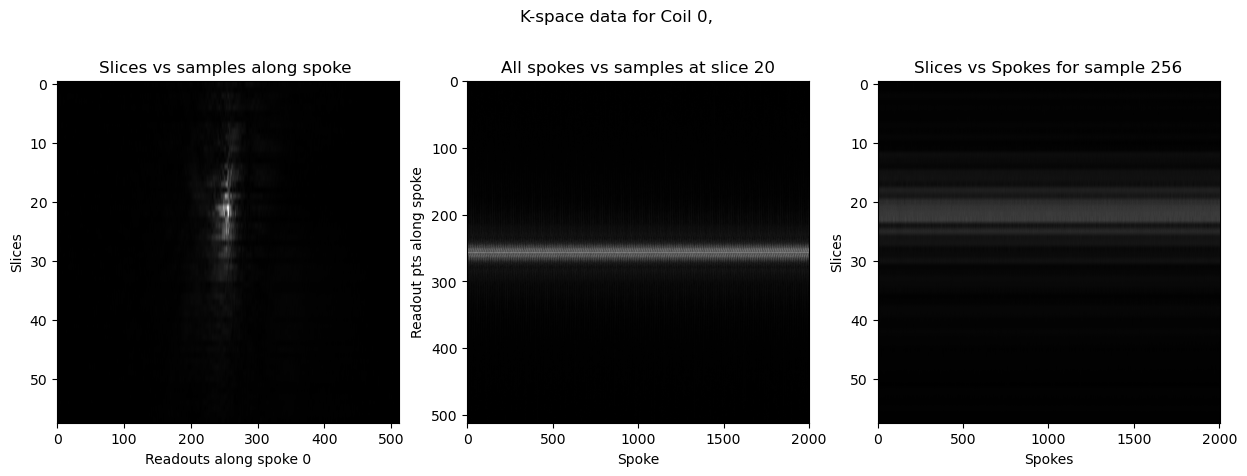

In [4]:
fig, ax = plot_ksp_data_multichannel(ksp_with_os, coil_idx=0, center_slice=20)

### Ungated recon

In [11]:
from sigpy.mri import dcf

def nufft_recon_ungated(data, coords, img_shape):

    dcf_ksp = dcf.pipe_menon_dcf(coords, img_shape)
    img_grid = sp.nufft_adjoint(data * dcf_ksp, coords)

    ## Save arrays
    return dcf_ksp, img_grid

In [ ]:
from raw_data_utils import get_kspace_data
from gating_functions import golden_angle_coords_3d


img_shape = (58, 512, 512)
coords = golden_angle_coords_3d(img_shape, num_spokes=2002, num_points=512)
dcf_ksp, img_grid = nufft_recon_ungated(ksp_with_os, coords)
save_data_helpers.write_pickle(dcf_ksp, '/home/lilianae/projects/naf_clean/recons/subject2_mid0082/dcf_ksp_512_ungated.pkl')
save_data_helpers.write_pickle(img_grid, '/home/lilianae/projects/naf_clean/recons/subject2_mid0082/img_grid_512_ungated.pkl')